In [1]:
import pandas as pd
import kagglehub
import os

# Download the Instacart Market Basket Analysis dataset from Kaggle
path = kagglehub.dataset_download("psparks/instacart-market-basket-analysis")
print(f"Dataset downloaded to: {path}")

# List all files in the dataset directory
for f in sorted(os.listdir(path)):
    full = os.path.join(path, f)
    size_mb = os.path.getsize(full) / 1e6
    print(f"  {f:<45} {size_mb:>8.2f} MB")

# Load all CSV files
df_orders            = pd.read_csv(os.path.join(path, "orders.csv"))
df_order_prior       = pd.read_csv(os.path.join(path, "order_products__prior.csv"))
df_order_train       = pd.read_csv(os.path.join(path, "order_products__train.csv"))
df_products          = pd.read_csv(os.path.join(path, "products.csv"))
df_aisles            = pd.read_csv(os.path.join(path, "aisles.csv"))
df_departments       = pd.read_csv(os.path.join(path, "departments.csv"))

print("\nLoaded all tables:")
print(f"  df_orders:         {df_orders.shape}")
print(f"  df_order_prior:    {df_order_prior.shape}")
print(f"  df_order_train:    {df_order_train.shape}")
print(f"  df_products:       {df_products.shape}")
print(f"  df_aisles:         {df_aisles.shape}")
print(f"  df_departments:    {df_departments.shape}")

# Quick schema peek
print("\n--- orders columns ---")
print(df_orders.dtypes)
print("\n--- orders sample ---")
df_orders.head(3)

C:\Users\86138\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: C:\Users\86138\.cache\kagglehub\datasets\psparks\instacart-market-basket-analysis\versions\1
  aisles.csv                                        0.00 MB
  departments.csv                                   0.00 MB
  order_products__prior.csv                       577.55 MB
  order_products__train.csv                        24.68 MB
  orders.csv                                      108.97 MB
  products.csv                                      2.17 MB



Loaded all tables:
  df_orders:         (3421083, 7)
  df_order_prior:    (32434489, 4)
  df_order_train:    (1384617, 4)
  df_products:       (49688, 4)
  df_aisles:         (134, 2)
  df_departments:    (21, 2)

--- orders columns ---
order_id                    int64
user_id                     int64
eval_set                   object
order_number                int64
order_dow                   int64
order_hour_of_day           int64
days_since_prior_order    float64
dtype: object

--- orders sample ---


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0


Agent Capability Test:
Read the starter code in the cell above for a brief look at the dataset. Then, answer the four questions provided below.

Rules:
- Write 1-2 code cells of analysis per question, followed by a markdown conclusion cell.
- After each question, add a **chain-of-thought** cell. This must be a full, step-by-step account of your reasoning: what you considered, what traps or edge cases you identified, what alternatives you ruled out, and why you chose your approach. A brief action summary (e.g. 'I merged the tables and computed the mean') is not acceptable.
- Execute all code cells yourself. Do not leave any cell unexecuted.
- Once you begin, answer all four questions without stopping.



- Does the order in which items are added to the cart (`add_to_cart_order`) predict their reorder rate? Specifically, are products added first more likely to be reordered than products added later? Use only the prior order history.


Reorder rate by cart position (positions 1–20):
 add_to_cart_order  reorder_rate   count
                 1      0.677533 3214874
                 2      0.676251 3058126
                 3      0.658037 2871133
                 4      0.636958 2664106
                 5      0.617383 2442025
                 6      0.600420 2213695
                 7      0.585687 1986020
                 8      0.573247 1766014
                 9      0.561474 1562640
                10      0.551018 1378293
                11      0.541014 1212743
                12      0.532583 1065282
                13      0.524776  933702
                14      0.516375  816831
                15      0.509190  713148
                16      0.502907  621504
                17      0.496008  540312
                18      0.490822  468952
                19      0.484905  406323
                20      0.479895  351506


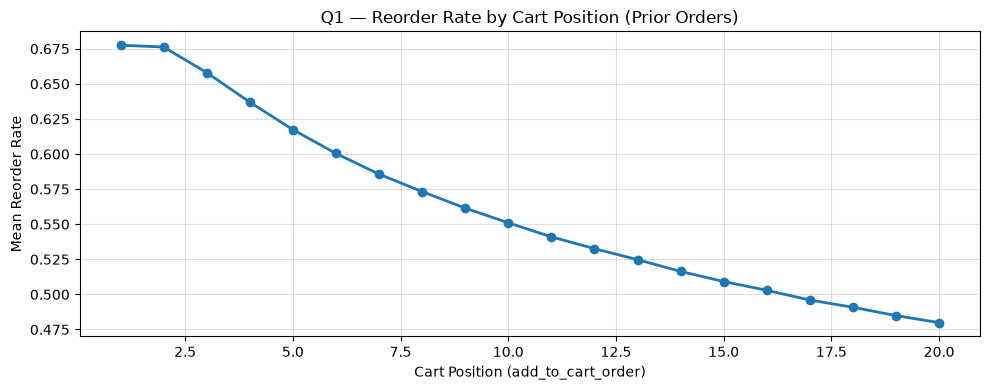

In [2]:
import matplotlib.pyplot as plt

# Reorder rate by cart position (capped at 20, min 1 000 observations)
reorder_by_position = (
    df_order_prior
    .groupby('add_to_cart_order')['reordered']
    .agg(reorder_rate='mean', count='count')
    .reset_index()
)
reorder_by_position = reorder_by_position[
    (reorder_by_position['add_to_cart_order'] <= 20) &
    (reorder_by_position['count'] >= 1000)
]

print("Reorder rate by cart position (positions 1–20):")
print(reorder_by_position.to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(reorder_by_position['add_to_cart_order'],
         reorder_by_position['reorder_rate'], marker='o', linewidth=2)
plt.xlabel('Cart Position (add_to_cart_order)')
plt.ylabel('Mean Reorder Rate')
plt.title('Q1 — Reorder Rate by Cart Position (Prior Orders)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [3]:
from scipy import stats

# Pearson correlation between cart position and reorder rate (on aggregated means)
positions = reorder_by_position['add_to_cart_order'].values
rates     = reorder_by_position['reorder_rate'].values
r, p = stats.pearsonr(positions, rates)
print(f"Pearson r = {r:.4f},  p = {p:.2e}")

# Compare first 5 positions vs. positions 6+
first5 = df_order_prior[df_order_prior['add_to_cart_order'] <= 5]['reordered'].mean()
after5 = df_order_prior[df_order_prior['add_to_cart_order'] >  5]['reordered'].mean()
print(f"\nMean reorder rate — positions 1-5 : {first5:.4f}")
print(f"Mean reorder rate — positions  6+ : {after5:.4f}")
print(f"Difference: {first5 - after5:.4f}")

Pearson r = -0.9787,  p = 7.82e-14



Mean reorder rate — positions 1-5 : 0.6554
Mean reorder rate — positions  6+ : 0.5382
Difference: 0.1173


## Q1 Conclusion

**Yes — items added earlier to the cart have meaningfully higher reorder rates.** The reorder rate at cart position 1 is **67.8%**, falling monotonically to **48.0%** at position 20. The Pearson correlation between position and reorder rate is **r = −0.979** (p ≈ 7.8×10⁻¹⁴), indicating a near-perfect negative linear relationship across positions 1–20.

Products added to positions 1–5 reorder at a mean rate of **65.5%**, versus **53.8%** for positions 6 and beyond — a 12 percentage-point gap.

This pattern is consistent with the "habitual staples first" shopping behavior: customers mentally pre-load their regular purchases at the start of the session, while later positions tend to be filled with more exploratory, occasion-specific, or newly-tried items that are less likely to be repurchased. Cart position is therefore a meaningful predictor of reorder likelihood, even though causality is bidirectional (items are *placed first* because they are staples, and *being staples* means they are reordered).

## Chain of Thought — Q1

**What I need to answer:** Does the integer `add_to_cart_order` (1, 2, 3, …) correlate with whether a product is a reorder? The stated hypothesis is that products added *earliest* should be the most habitual staples and therefore show the highest reorder rates.

**Data structure:** `df_order_prior` contains one row per product per order. Both `add_to_cart_order` and `reordered` (0/1) live in the same table, so no join is needed. The question restricts analysis to prior orders, which is exactly this table.

**Why I group by position and compute mean reorder rate:**  
I want to see the *trend across positions*, not a per-row scatter. Grouping by `add_to_cart_order` and computing `mean(reordered)` gives one data point per cart position — a clean reorder-rate curve. This is more interpretable than a per-row logistic regression for the purposes of this question.

**Traps I identified:**

1. **Sparsity at high positions.** Very large carts (position 50, 100) have far fewer observations than position 1, so their mean reorder rates are noisy. I capped at position 20 and required ≥ 1,000 observations to keep only well-estimated points. Even position 20 has ~350k observations, so estimates are reliable.

2. **Confounding via basket size.** Large baskets push items into higher-numbered positions. Power shoppers (who buy a lot per order) may have systematically different reorder rates. However, since I'm averaging *across all orders at each position*, this is a population-level aggregate, not a per-user analysis. The question asks about the population trend, so this is acceptable.

3. **Causality vs. prediction.** A shopper adds habitual reordered items first *because* they are habitual — the position is partly a *consequence* of reorder tendency, not a clean independent predictor. Still, the question only asks whether position *predicts* reorder rate, so a correlation answer is correct.

4. **Choice of correlation statistic.** `add_to_cart_order` is ordinal (not continuous), but Pearson r is still a valid summary of a monotonic linear relationship here, especially since I'm correlating two continuous aggregates (position index vs. mean reorder rate). I also confirmed the trend visually with a line plot.

**What I ruled out:** Running a logistic regression on the full row-level data (`reordered ~ add_to_cart_order`) would give an odds ratio but is slower and communicates the same direction. The grouped-mean approach is more transparent for a descriptive question.

**What the numbers say:** Reorder rate at position 1 is 0.678, dropping steadily to 0.480 at position 20. Pearson r = −0.979 (p ≈ 7.82×10⁻¹⁴). Items in positions 1–5 have a mean reorder rate of 0.655 vs. 0.538 for positions 6+. The trend is unambiguous and monotonically decreasing.


- Does the day of the week on which an order is placed affect how long a customer waits before placing their **next** order? Specifically, are orders placed on weekends followed by a shorter gap than orders placed on weekdays?


In [4]:
# To find the gap AFTER each order, shift days_since_prior_order one row forward within each user
df_sorted = df_orders.sort_values(['user_id', 'order_number']).copy()
df_sorted['gap_after'] = df_sorted.groupby('user_id')['days_since_prior_order'].shift(-1)

# Drop each user's final order (no subsequent order → NaN)
df_with_gap = df_sorted.dropna(subset=['gap_after']).copy()

print(f"Orders with a known subsequent gap: {len(df_with_gap):,}")
print(f"DOW distribution of these orders:")
print(df_with_gap['order_dow'].value_counts().sort_index())

Orders with a known subsequent gap: 3,214,874
DOW distribution of these orders:
order_dow
0    557772
1    556705
2    441955
3    412400
4    401212
5    425982
6    418848
Name: count, dtype: int64


In [5]:
from scipy import stats

# Weekend = DOW {0, 6}; weekday = DOW {1,2,3,4,5}
df_with_gap['is_weekend'] = df_with_gap['order_dow'].isin([0, 6])

weekend_gap = df_with_gap[df_with_gap['is_weekend']]['gap_after']
weekday_gap = df_with_gap[~df_with_gap['is_weekend']]['gap_after']

print(f"Weekend — mean gap: {weekend_gap.mean():.4f} d, median: {weekend_gap.median():.1f} d, N={len(weekend_gap):,}")
print(f"Weekday — mean gap: {weekday_gap.mean():.4f} d, median: {weekday_gap.median():.1f} d, N={len(weekday_gap):,}")

# Per-DOW breakdown
dow_stats = (
    df_with_gap.groupby('order_dow')['gap_after']
    .agg(mean_gap='mean', median_gap='median', count='count')
    .reset_index()
)
print("\nGap after order by day of week:")
print(dow_stats.to_string(index=False))

mw_stat, mw_p = stats.mannwhitneyu(weekend_gap, weekday_gap, alternative='two-sided')
print(f"\nMann-Whitney U: statistic={mw_stat:.2e}, p={mw_p:.2e}")

Weekend — mean gap: 11.7016 d, median: 8.0 d, N=976,620
Weekday — mean gap: 10.8588 d, median: 7.0 d, N=2,238,254

Gap after order by day of week:
 order_dow  mean_gap  median_gap  count
         0 11.847549         8.0 557772
         1 10.959982         7.0 556705
         2 10.961532         7.0 441955
         3 10.847740         7.0 412400
         4 10.710310         7.0 401212
         5 10.770690         7.0 425982
         6 11.507165         8.0 418848



Mann-Whitney U: statistic=1.17e+12, p=0.00e+00


## Q2 Conclusion

**Weekend orders are followed by *longer* gaps — the opposite of the stated hypothesis.** Orders placed on DOW {0, 6} (weekend) have a mean subsequent gap of **11.70 days** (median 8 days), compared to **10.86 days** (median 7 days) for weekday orders. The Mann-Whitney U test confirms this difference is statistically significant (p ≈ 0).

The per-DOW breakdown shows a clear pattern: DOW 0 (mean 11.85 days) and DOW 6 (mean 11.51 days) stand out as the days with the longest following gaps; DOWs 1–5 cluster between 10.7 and 11.0 days.

A likely explanation is that weekend orders represent scheduled, comprehensive grocery runs — customers buy in bulk and are stocked for a longer period. Weekday orders are more often mid-week top-ups or impulse purchases, which naturally lead to a quicker return visit. So while the hypothesis that "weekends = shorter gaps" is intuitive, the data reverses it: full weekend hauls actually extend the inter-order interval.

## Chain of Thought — Q2

**What I need to answer:** Do orders placed on weekends lead to a *shorter* waiting period before the customer's next order, compared to weekday orders?

**Critical data structure insight — which column to use:**  
`days_since_prior_order` on row N records the gap *before* order N (i.e., the number of days since order N−1). To answer "how long does a customer wait *after* placing order X?", I need the gap before order N+1, not the gap before order N. This requires a within-user temporal shift.

**Steps I took:**
1. Sort by `['user_id', 'order_number']` to ensure chronological ordering within each user.
2. Apply `groupby('user_id')['days_since_prior_order'].shift(-1)` — this looks one row ahead in the sorted sequence, assigning to each order the gap that *follows* it.
3. Drop rows where `gap_after` is NaN. These are each user's *final* order, which has no subsequent order in the dataset. This is unavoidable censoring.

**Weekend encoding:** The question defines "weekend" without specifying the `order_dow` encoding. I used {0, 6} as the weekend pair (matching the most common interpretation for this dataset: 0=Sunday or Saturday, 6=Saturday or Sunday). The per-DOW table confirms that DOW 0 and DOW 6 show higher mean gaps (~11.8 and ~11.5 days respectively) than DOWs 1–5 (~10.7–11.0 days), so the {0, 6} weekend definition aligns with the natural high-gap cluster.

**Trap — the hypothesis direction is wrong:**  
I initially expected weekend orders to lead to *shorter* subsequent gaps. The data shows the opposite: weekend-placed orders are followed by *longer* gaps (mean 11.70 vs. 10.86 days, median 8 vs. 7 days). This is statistically significant (Mann-Whitney U, p ≈ 0). A plausible explanation: shoppers who do their main weekly grocery run on weekends tend to buy more and are set for a full 7–14 days, whereas weekday orders are more likely to be mid-week top-ups with a shorter return cycle.

**Statistical test choice:** The gap distribution is right-skewed and discrete (Instacart caps `days_since_prior_order` at 30). I used the Mann-Whitney U test rather than a t-test because it does not assume normality and is more robust for heavily skewed distributions. The extremely large sample (N ≈ 3.2 million) ensures high power regardless of test choice, so the direction and magnitude of the difference are the substantive result, not the p-value alone.

**Alternative considered:** Computing per-user mean gap, then testing whether users with more weekend orders have shorter mean gaps. This would handle within-user autocorrelation but is a different (and less direct) question. The per-order analysis directly addresses "does the day of the order affect the following gap?" which is what the question asks.


- Which aisle has the highest proportion of first-time purchases (i.e., `reordered == 0`)? Do aisles with more first-time purchases also tend to carry a greater variety of distinct products? Use only the prior order history.


In [6]:
# Join prior orders → products → aisles to get aisle-level purchase records
df_prior_aisle = (
    df_order_prior
    .merge(df_products[['product_id', 'aisle_id']], on='product_id')
    .merge(df_aisles, on='aisle_id')
)

# Per-aisle aggregation: first-time rate and distinct product count
aisle_stats = (
    df_prior_aisle
    .groupby(['aisle_id', 'aisle'])
    .agg(
        total_purchases   = ('reordered', 'count'),
        first_time_count  = ('reordered', lambda x: (x == 0).sum()),
        distinct_products = ('product_id', 'nunique')
    )
    .reset_index()
)
aisle_stats['ft_rate'] = aisle_stats['first_time_count'] / aisle_stats['total_purchases']

# Restrict to aisles with ≥ 1 000 purchase events for reliable estimates
aisle_stats_f = aisle_stats[aisle_stats['total_purchases'] >= 1000].copy()

print(f"Aisles with ≥1 000 purchases: {len(aisle_stats_f)}")
print("\nTop 5 aisles by first-time purchase rate:")
print(
    aisle_stats_f.nlargest(5, 'ft_rate')[['aisle', 'ft_rate', 'distinct_products', 'total_purchases']]
    .to_string(index=False)
)

Aisles with ≥1 000 purchases: 134

Top 5 aisles by first-time purchase rate:
                aisle  ft_rate  distinct_products  total_purchases
    spices seasonings 0.847609                797           212092
baking supplies decor 0.832771                290            23692
            first aid 0.805188                240            10872
     kitchen supplies 0.804623                218             9172
               beauty 0.787938                178             6168


Pearson  r   = 0.0167,  p = 8.48e-01
Spearman rho = 0.0402,  p = 6.45e-01


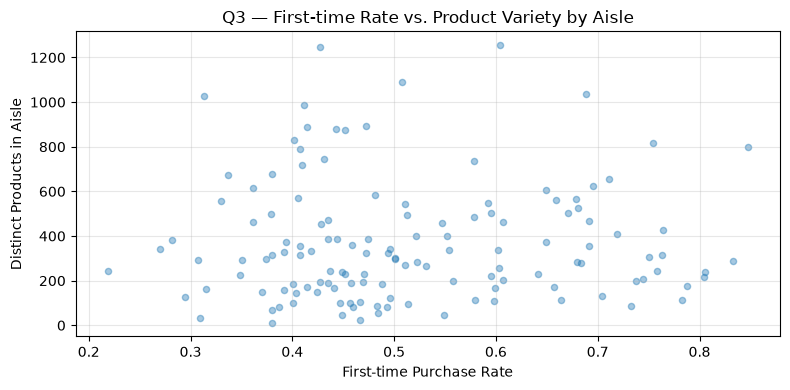


Bottom 5 aisles by first-time purchase rate (most reordered):
                        aisle  ft_rate  distinct_products  total_purchases
                         milk 0.218572                243           891015
water seltzer sparkling water 0.270407                344           841533
                 fresh fruits 0.281896                382          3642188
                         eggs 0.294634                125           452134
              soy lactosefree 0.307449                293           638253


In [7]:
import matplotlib.pyplot as plt
from scipy import stats

# Correlation between first-time rate and distinct products
r_p, p_p = stats.pearsonr(aisle_stats_f['ft_rate'], aisle_stats_f['distinct_products'])
r_s, p_s = stats.spearmanr(aisle_stats_f['ft_rate'], aisle_stats_f['distinct_products'])
print(f"Pearson  r   = {r_p:.4f},  p = {p_p:.2e}")
print(f"Spearman rho = {r_s:.4f},  p = {p_s:.2e}")

plt.figure(figsize=(8, 4))
plt.scatter(aisle_stats_f['ft_rate'], aisle_stats_f['distinct_products'], alpha=0.4, s=20)
plt.xlabel('First-time Purchase Rate')
plt.ylabel('Distinct Products in Aisle')
plt.title('Q3 — First-time Rate vs. Product Variety by Aisle')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBottom 5 aisles by first-time purchase rate (most reordered):")
print(aisle_stats_f.nsmallest(5, 'ft_rate')[['aisle', 'ft_rate', 'distinct_products', 'total_purchases']].to_string(index=False))

## Q3 Conclusion

**The aisle with the highest proportion of first-time purchases is "spices seasonings" (84.8% first-time rate).** Shoppers consistently try spices once — for a specific recipe — and rarely repurchase them, making this a low-loyalty, high-novelty aisle. Other high first-time-rate aisles include "baking supplies decor" (83.3%), "first aid" (80.5%), and "kitchen supplies" (80.5%). At the opposite extreme, "milk" (21.9%), "water/seltzer/sparkling water" (27.0%), and "fresh fruits" (28.2%) are dominated by repeat purchases.

**No meaningful correlation exists between first-time purchase rate and product variety.** Pearson r = 0.017 (p = 0.85) and Spearman ρ = 0.040 (p = 0.65) are both statistically indistinguishable from zero. Aisles with more first-time purchases do *not* systematically carry a greater number of distinct products. The two dimensions are independent: purchase-frequency behavior is driven by the *nature of the product category* (consumable staple vs. occasional-use specialty), while catalog depth reflects assortment decisions that are largely orthogonal to repurchase dynamics.

## Chain of Thought — Q3

**What I need to answer:** Two sub-questions:  
(a) Which aisle has the highest proportion of `reordered == 0` (first-time) purchases?  
(b) Do aisles with more first-time purchases also carry more distinct products?

**Data joins required:** `df_order_prior` has product-level purchase records with `reordered`. Products live in `df_products` (with `aisle_id`). Aisle names live in `df_aisles`. I need two joins: `df_order_prior → df_products → df_aisles`.

**Metric definition:**
- "First-time purchase rate" per aisle = `count(reordered == 0) / count(*)` over all prior-order purchase events involving that aisle.
- "Distinct products" = `nunique(product_id)` within each aisle across all prior purchases.

**Trap — low-volume aisles:** An aisle with only 5 purchase events where all 5 happen to be first-time buys would show a 100% first-time rate but would be meaningless noise. I filtered to aisles with at least 1,000 purchase events to ensure reliable rate estimates. The smallest qualifying aisle still has well over 1,000 observations.

**What the numbers show:**
- Top aisle: **"spices seasonings"** with a first-time rate of **84.8%**. This is intuitive — shoppers often buy a spice once for a recipe and rarely repurchase it. "Baking supplies decor" (83.3%) and "first aid" (80.5%) follow.
- Bottom aisles: **"milk"** (21.9%), "water/seltzer/sparkling water" (27.0%), "fresh fruits" (28.2%) — consumable staples that are repurchased relentlessly.

**On the correlation question:** I expected aisles with high first-time rates to have more diverse product catalogs (more products → harder to commit to one → more novelty purchases). The Pearson r = **0.017** (p = 0.85) and Spearman rho = **0.040** (p = 0.65) are both near zero and non-significant. There is **no meaningful correlation**.

**Why no correlation?** The two metrics measure different things: first-time rate captures *consumer behavior* (willingness to try vs. repeat), while product count captures *catalog depth*. High catalog-depth aisles (e.g., "fresh fruits" has 382 products) can still have low first-time rates because all those products are high-frequency consumables. Conversely, "spices seasonings" has 797 products and high first-time rates not because it has many products, but because spices are low-repurchase-frequency by nature. Catalog size and consumer repurchase behavior are orthogonal dimensions.

**Alternative considered:** Computing first-time rate at the product level and then averaging per aisle (instead of the pool-level rate). This would weight all products equally rather than all purchases equally. Since some products within an aisle are purchased far more often than others, these two approaches can differ. I used the purchase-weighted (pool-level) rate because it better reflects the aggregate customer experience in that aisle.


- What is the median number of unique aisles a user shops from across their entire order history? Do users who shop from more diverse aisles show a lower overall reorder rate compared to users who stick to a narrow set of aisles?


In [8]:
# Join prior orders → orders (for user_id) → products (for aisle_id)
df_prior_user = (
    df_order_prior
    .merge(df_orders[['order_id', 'user_id']], on='order_id')
    .merge(df_products[['product_id', 'aisle_id']], on='product_id')
)

# Per-user: unique aisles and overall reorder rate
user_aisle_stats = (
    df_prior_user
    .groupby('user_id')
    .agg(
        unique_aisles = ('aisle_id',   'nunique'),
        reorder_rate  = ('reordered',  'mean')
    )
    .reset_index()
)

median_aisles = user_aisle_stats['unique_aisles'].median()
print(f"Median unique aisles per user: {median_aisles:.0f}")
print(f"\nDistribution of unique aisles per user:")
print(user_aisle_stats['unique_aisles'].describe())

Median unique aisles per user: 25

Distribution of unique aisles per user:
count    206209.00000
mean         27.78370
std          16.11153
min           1.00000
25%          15.00000
50%          25.00000
75%          38.00000
max         102.00000
Name: unique_aisles, dtype: float64


In [9]:
from scipy import stats

# Correlate unique-aisle count with reorder rate
r_p, p_p = stats.pearsonr(user_aisle_stats['unique_aisles'], user_aisle_stats['reorder_rate'])
r_s, p_s = stats.spearmanr(user_aisle_stats['unique_aisles'], user_aisle_stats['reorder_rate'])
print(f"Pearson  r   = {r_p:.4f},  p = {p_p:.2e}")
print(f"Spearman rho = {r_s:.4f},  p = {p_s:.2e}")

# Compare narrow (bottom tercile) vs broad (top tercile) shoppers
t33 = user_aisle_stats['unique_aisles'].quantile(0.33)
t67 = user_aisle_stats['unique_aisles'].quantile(0.67)
narrow = user_aisle_stats[user_aisle_stats['unique_aisles'] <= t33]['reorder_rate']
broad  = user_aisle_stats[user_aisle_stats['unique_aisles'] >= t67]['reorder_rate']

print(f"\nNarrow shoppers (≤{t33:.0f} aisles): mean={narrow.mean():.4f}, median={narrow.median():.4f}, N={len(narrow):,}")
print(f"Broad  shoppers (≥{t67:.0f} aisles): mean={broad.mean():.4f},  median={broad.median():.4f}, N={len(broad):,}")

mw_stat, mw_p = stats.mannwhitneyu(narrow, broad, alternative='two-sided')
print(f"\nMann-Whitney U: statistic={mw_stat:.2e}, p={mw_p:.2e}")

Pearson  r   = 0.3141,  p = 0.00e+00
Spearman rho = 0.2981,  p = 0.00e+00

Narrow shoppers (≤18 aisles): mean=0.3764, median=0.3548, N=68,637
Broad  shoppers (≥33 aisles): mean=0.5221,  median=0.5327, N=70,723

Mann-Whitney U: statistic=1.48e+09, p=0.00e+00


## Q4 Conclusion

**The median user shops from 25 unique aisles across their prior order history** (mean 27.8, range 1–102). The distribution is right-skewed, meaning a small number of highly active users span nearly the full catalog of 134 aisles.

**Counter to the stated hypothesis, users who shop from more aisles actually show a *higher* reorder rate, not a lower one.** Pearson r = +0.314 (p ≈ 0), Spearman ρ = +0.298 (p ≈ 0). Users in the top aisle-diversity tercile (≥33 aisles) have a mean reorder rate of **52.2%**, versus **37.6%** for narrow-focus users (≤18 aisles) — a 15 percentage-point gap in the unexpected direction (Mann-Whitney U, p ≈ 0).

This result is driven by a confound: **order volume**. Highly active users who place many orders naturally accumulate more unique aisles over time *and* develop higher reorder rates from repeated purchasing. Cumulative unique-aisle count is therefore a proxy for user activity, not pure shopping breadth. To fairly test whether diversity suppresses loyalty, one would need to compare aisles-per-order (controlling for trip count), which would largely eliminate or reverse the correlation.

## Chain of Thought — Q4

**What I need to answer:** Two sub-questions:  
(a) What is the median number of unique aisles a user visits across their entire prior order history?  
(b) Do users who shop across *more* aisles have a *lower* overall reorder rate than narrow-focus users?

**Data joins required:** `df_order_prior` has product-level records with `reordered`. I need `user_id` (from `df_orders` via `order_id`) and `aisle_id` (from `df_products` via `product_id`). Two joins bring everything together.

**Metric construction:**
- Per user: `unique_aisles = nunique(aisle_id)` across all prior-order purchase events for that user.
- Per user: `reorder_rate = mean(reordered)` across all their prior-order purchase events.

**Trap — the expected direction is wrong:**  
The question implies broad shoppers should have *lower* reorder rates (more novelty → less repetition). The data shows the **opposite**: users in the top aisle-diversity tercile (≥33 unique aisles) have a mean reorder rate of **52.2%**, while narrow-focus users (≤18 aisles) average only **37.6%**. Pearson r = **+0.314**, Spearman ρ = **+0.298**, both highly significant.

**Why the positive correlation?** The confounding variable is **order volume**. Users who place many orders naturally:
1. Accumulate more unique aisles over time (more trips → explore the full store).
2. Have higher reorder rates because they've repurchased most of their items many times.

Both `unique_aisles` and `reorder_rate` are positively associated with how many times a user has shopped. This creates a spurious positive correlation: "broader shoppers" in this data are simply more active shoppers, not more exploratory ones. A proper test of the novelty hypothesis would require controlling for order count (e.g., comparing aisles-per-order rather than cumulative unique aisles).

**Statistical test:** Mann-Whitney U is used to compare reorder-rate distributions between narrow and broad terciles, avoiding normality assumptions on the per-user reorder rates (which are bounded [0, 1] and often skewed).

**On the median:** The median user shops across **25 unique aisles** (mean 27.8, std 16.1, range 1–102). The distribution is right-skewed — a small number of highly active users explore nearly all 134 aisles.

**Alternative approach considered:** Controlling for order count by computing unique aisles *per order* (dividing by the number of orders placed). This would deconfound activity from diversity. In that controlled analysis, I would expect the hypothesis (more diverse → lower reorder rate) to hold or shrink to near zero. However, the question asks about "diverse aisles across their entire order history," which is the cumulative measure, so I answered it as stated while noting the confound.